In [5]:
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path
from collections import OrderedDict
from modules.utils import compare_preds, format_time, natural_casing
from typing import NamedTuple

import abc
import pandas as pd
import time
import pprint
import textwrap

## Load Dataset

Read all splits and concat them

In [6]:
csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_merged : pd.DataFrame = pd.concat(
    [bzkopen_train, bzkopen_val, bzkopen_test], 
    keys=['train', 'val', 'test'], 
    names=['split', 'row']
)
bzkopen_merged

field                            FullAddress  \
split row                                                                   
train 0        ApplicantBirthPlace                                Ruskowa   
      1    ApplicantCurrentAddress  170 Clymer Street, Brooklyn, N.Y. USA   
      2        ApplicantBirthPlace                              Drohobycz   
      3    ApplicantCurrentAddress   London N.W.3/England, 109 Green Hill   
      4           VictimBirthPlace                                Dresden   
...                            ...                                    ...   
test  147  ApplicantCurrentAddress  2114-79 St. Jackson Heights. N.Y. USA   
      148         VictimBirthPlace                             Losone CSR   
      149     VictimCurrentAddress     1544, Union St., Brooklyn, 13 N.Y.   
      150      ApplicantBirthPlace                                   Rum.   
      151  ApplicantCurrentAddress         Bnei Brack Isr. Raw Oto St. 16   

          UnitNumber HouseNumber     StreetName     Neighborhood        City  \
split row                                                                      
train 0          NaN         NaN            NaN              NaN     Ruskowa   
      1          NaN         170  Clymer Street         Brooklyn        N.Y.   
      2          NaN         NaN            NaN              NaN   Drohobycz   
      3          NaN         109     Green Hill              NaN      London   
      4          NaN         NaN            NaN              NaN     Dresden   
...              ...         ...            ...              ...         ...   
test  147        NaN        2114         79 St.  Jackson Heights        N.Y.   
      148        NaN         NaN            NaN              NaN      Losone   
      149        NaN        1544      Union St.              NaN    Brooklyn   
      150        NaN         NaN            NaN              NaN         NaN   
      151        NaN          16    Raw Oto St.              NaN  Bnei Brack   

          District   Region State Country    PostalCode  
split row                                                
train 0        NaN      NaN   NaN     NaN           NaN  
      1        NaN      NaN   NaN     USA           NaN  
      2        NaN      NaN   NaN     NaN           NaN  
      3        NaN  England   NaN     NaN  London N.W.3  
      4        NaN      NaN   NaN     NaN           NaN  
...            ...      ...   ...     ...           ...  
test  147      NaN      NaN   NaN     USA           NaN  
      148      NaN      NaN   NaN     CSR           NaN  
      149      NaN      NaN  N.Y.     NaN   Brooklyn 13  
      150      NaN      NaN   NaN    Rum.           NaN  
      151      NaN      NaN   NaN    Isr.           NaN  

[1075 rows x 12 columns]

# Dataset Statistics

In [7]:
dataset_statistics = pd.concat(
    [
        bzkopen_merged[["FullAddress"]].rename(columns={"FullAddress": "AllAddresses"}),
        bzkopen_merged.pivot(columns="field", values="FullAddress"),
        bzkopen_merged.drop(columns=["field", "FullAddress"]),
    ]
).describe(include='all').T.drop(columns=["top", "freq"]).rename(index=natural_casing)

display(dataset_statistics)

,count,unique
All Addresses,1075,813
Applicant Birth Place,346,253
Applicant Current Address,349,289
Victim Birth Place,172,133
Victim Current Address,134,114
Victim Death Place,74,56
Unit Number,52,36
House Number,417,190
Street Name,419,329
Neighborhood,110,77


In [8]:
display(bzkopen_merged["Country"].value_counts().to_frame())

,count
Country,
Polen,70
Israel,61
USA,37
Rumänien,11
Ungarn,11
Rum.,8
Brasilien,8
Bulg.,6
Russland,6


In [27]:
country_normalize_mapping = {
    ("Polen", "Po.") : "Poland", ("USA.", "U.S.A.") : "USA", ("Isr.",) : "Israel", 
    ("Rumänien", "Rumaenien", "Rum.", "Rum. jetzt SSRU") : "Romania", 
    ("Ungarn", "Ung.", "Ungarn."): "Hungary", ("Brasilien", "Bras.") : "Brazil",
    ("Bulg.",) : "Bulgaria", ("Russland",) : "Russia", ("CSR",) : "Czechslovakia", 
    ("Argentinien", "Argenti- nien", "Argent.") : "Argentina", ("Frankreich", "Frankr.") : "France", 
    ("Australien", "Austr.") : "Australia", ("Schweiz",) : "Switzerland", ("Schweden",) : "Sweden", 
    ("Türkey",) : "Turkey", ("Österreich", "Österr.") : "Austria", ("Griechenland", "Griechenld") : "Greece",
    ("Italien",) : "Italy", ("Jug.", "Jugoslavien", "Jugl.") : "Yugoslavia", ("Norwegen") : "Norway",
    ("Mo.",) : "Monaco", ("Lettland",) : "Latvia", ("Litauen",) : "Lithuania"
}

country_normalize_mapping = {
    alias.lower() : normalized 
    for aliases, normalized in country_normalize_mapping.items() 
    for alias in aliases
} | {
    normalized.lower() : normalized
    for normalized in country_normalize_mapping.values()
}

normalized_country = bzkopen_merged["Country"].apply(
    lambda c: country_normalize_mapping.get(c.lower(), c) if isinstance(c, str) else "No Country"
)
country_counts = normalized_country.value_counts().to_frame()
display(country_counts)

,count
Country,
No Country,773
Poland,73
Israel,66
USA,46
Romania,22
Hungary,14
Brazil,9
Russia,9
France,8


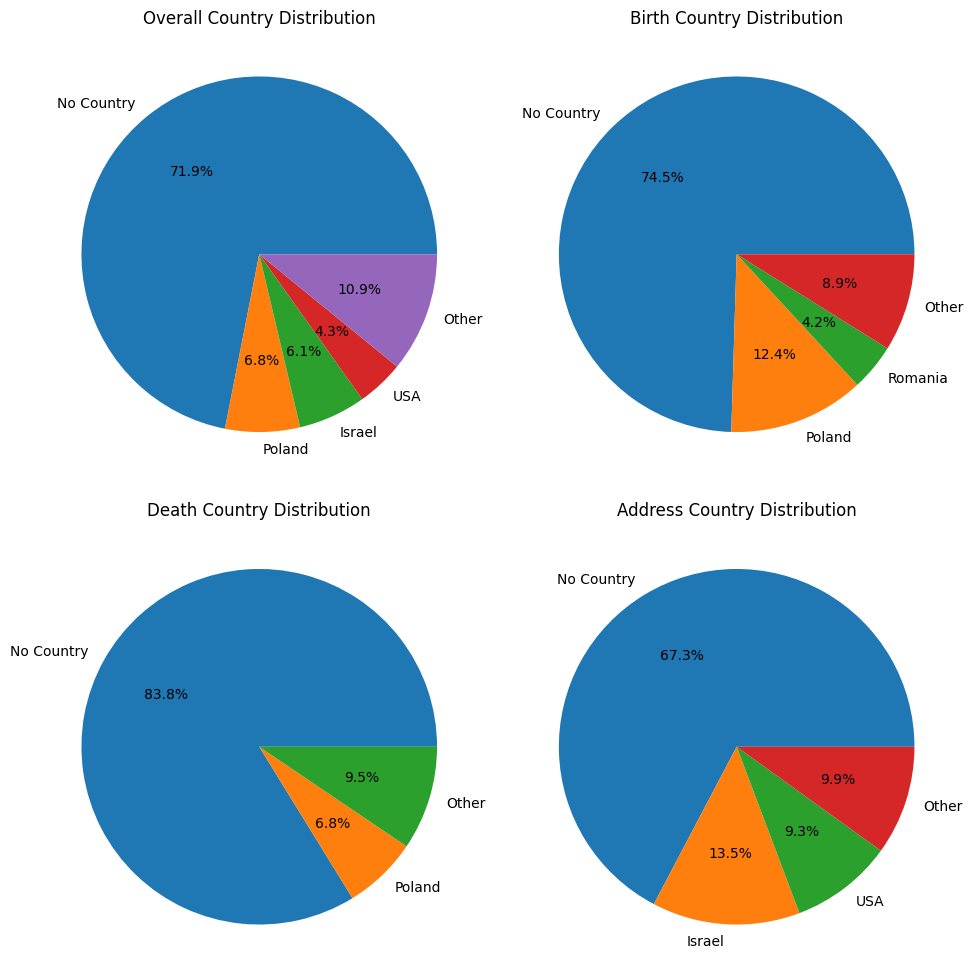

In [58]:
def summarize_counts(counts: pd.DataFrame, thresh: float = 0.04) -> pd.DataFrame:
    mask = (counts["count"] / counts["count"].sum()) >= thresh
    summarized_counts = counts[mask]
    summarized_counts.loc["Other"] = counts[~mask].sum()
    return summarized_counts
summarized_country_counts = summarize_counts(country_counts)

country_per_field_type = bzkopen_merged[["field"]].merge(
    normalized_country, left_index=True, right_index=True
)
birth_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Birth")]["Country"].value_counts().to_frame()
birth_country_counts = summarize_counts(birth_country_counts)
death_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Death")]["Country"].value_counts().to_frame()
death_country_counts = summarize_counts(death_country_counts)
address_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Address")]["Country"].value_counts().to_frame()
address_country_counts = summarize_counts(address_country_counts)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
summarized_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[0, 0], title="Overall Country Distribution")
birth_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[0, 1], title="Birth Country Distribution")
death_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 0], title="Death Country Distribution")
address_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 1], title="Address Country Distribution")
plt.tight_layout()